In [1]:
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler
from time import time

from helpers import Material, apply_psf, get_wavelen, get_wavenum

import jax
import jax.numpy as jnp

import chromatix.functional as cx
from chromatix.ops import init_plane_resample

import optax
from jaxopt.projection import projection_non_negative
from flax import linen as nn
from flax.core import unfreeze, freeze

In [2]:
# Figure settings

from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

def add_scalebar(ax, sz, Nx, real_dx, real_units, color='k', sv=1):
    width_px = sz * Nx 
    label = f'{real_dx * width_px:.0f} {real_units}'
    scalebar = AnchoredSizeBar(ax.transData, width_px, label, 'lower left', size_vertical=sv, frameon=False, color=color)
    ax.add_artist(scalebar)
    
custom_cycler = cycler('color', ['#0072B2', '#009E73', '#F0E442', '#D55E00', '#CC79A7'])  # color-blind friendly

plt.rcParams.update({
    'figure.dpi': 300,
    'font.size':10,
    'axes.titlesize':10,
    'axes.labelsize':8,
    'axes.linewidth': .5,
    'axes.prop_cycle': custom_cycler,
    'xtick.top': True, 
    'ytick.right': True, 
    'xtick.direction': 'in', 
    'ytick.direction': 'in',
    'xtick.labelsize':8,
    'ytick.labelsize':8,
    'legend.fontsize': 8,
    'lines.linewidth':1,
    'image.cmap':'gray',
    'text.usetex': True,
    'font.family': 'serif'
})


In [3]:
# Material definitions 

### from NIST
adip = Material('adipose', 'H(11.4)C(59.8)N(0.7)O(27.8)Na(0.1)S(0.1)Cl(0.1)', 0.95)
gland = Material('gland', 'H(10.2)C(18.4)N(3.2)O(67.6)', 1.05)
bone = Material('bone', 'H(3.4)C(15.5)N(4.2)O(43.5)Na(0.1)Mg(0.2)P(10.3)S(0.3)Ca(22.5)', 1.92)
tissue = Material('soft tissue', 'H(10.2)C(14.3)N(3.4)O(70.8)Na(0.2)P(0.3)S(0.3)Cl(0.2)K(0.3)', 1.06)   
breast = Material('breast tissue', 'H(10.6)C(33.2)N(3.0)O(52.7)Na(0.1)P(0.1)S(0.2)Cl(0.1)', 1.0)
water = Material('water', 'H(11.2)O(88.8)', 1.0)

### breast calcifications
# Type I: Calcium oxalate dihydrate (CaC2O4·2H2O)
calc1 = Material(
    name = 'Type I',
    matcomp = 'Ca(24.43)C(14.64)O(58.49)H(2.44)',
    density = 2.0  # effective vs 2.20  # g/cm^3
)

# Type II: Hydroxyapatite (Ca5(PO4)3OH)
calc2 = Material(
    name = 'Type II',
    matcomp = 'Ca(39.89)P(18.50)O(41.41)H(0.20)',
    density = 2.8  # effective vs 3.05  # g/cm^3 (biological apatite ~2.9–3.1)
)

# Load polychromatic spectrum

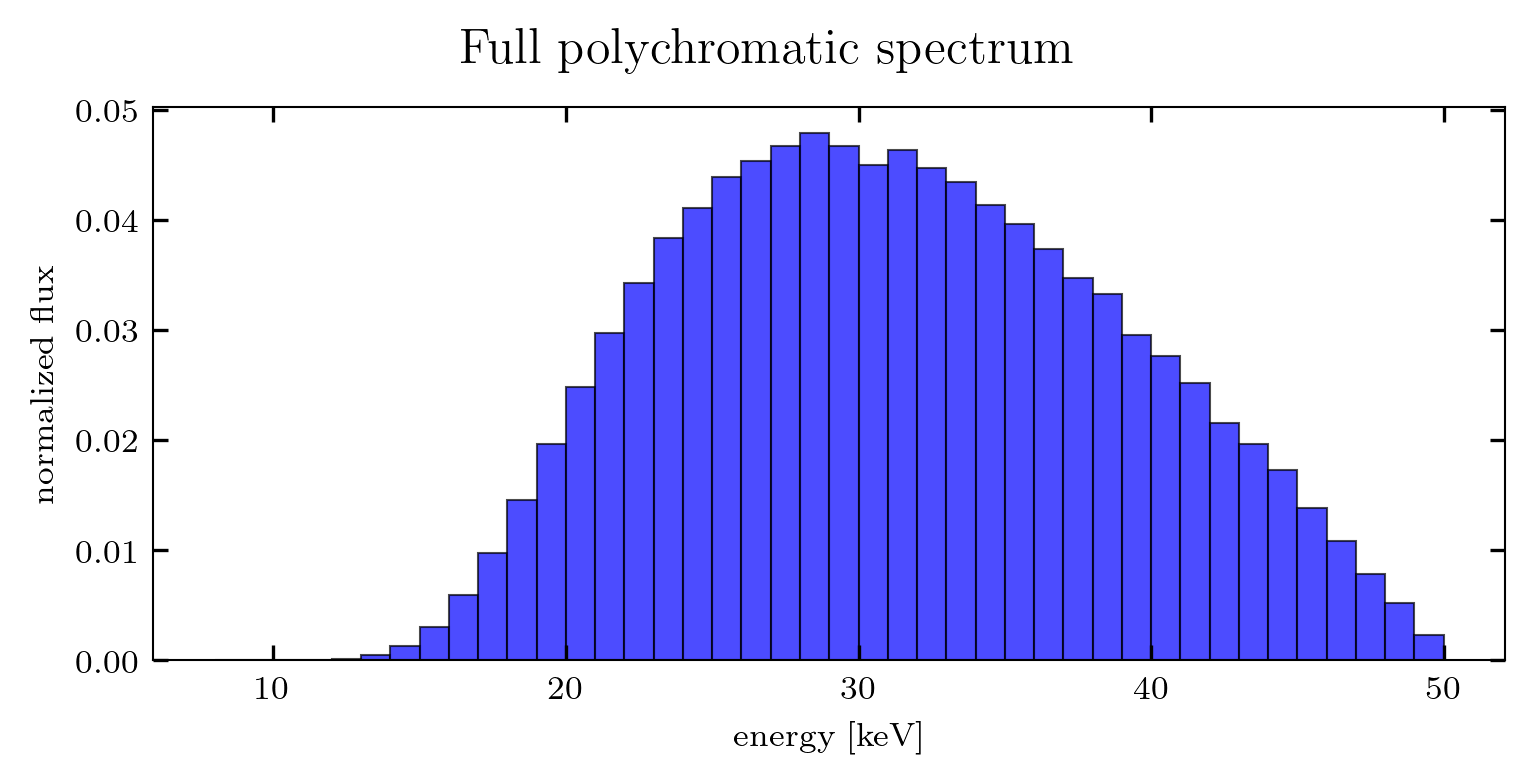

In [4]:
with open('tasmics_50kVp_2mmAl.csv', 'r') as f:
    spectrum = np.array([line.split(',') for line in f.readlines()[1:]], dtype=float).T
    spectrum = spectrum[:, spectrum[1] > 1e-3]  # remove 0s for speed
    spectrum[1] /= np.sum(spectrum[1])          # normalize total counts

fig, ax = plt.subplots(figsize=[5,2.5], dpi=300, layout='constrained')
fig.suptitle('Full polychromatic spectrum')
ax.set_ylabel('normalized flux')
ax.set_xlabel('energy [keV]')
ax.bar(spectrum[0], spectrum[1], width=1, align='center', edgecolor='k', color='b', linewidth=0.5, alpha=0.7)
plt.show()

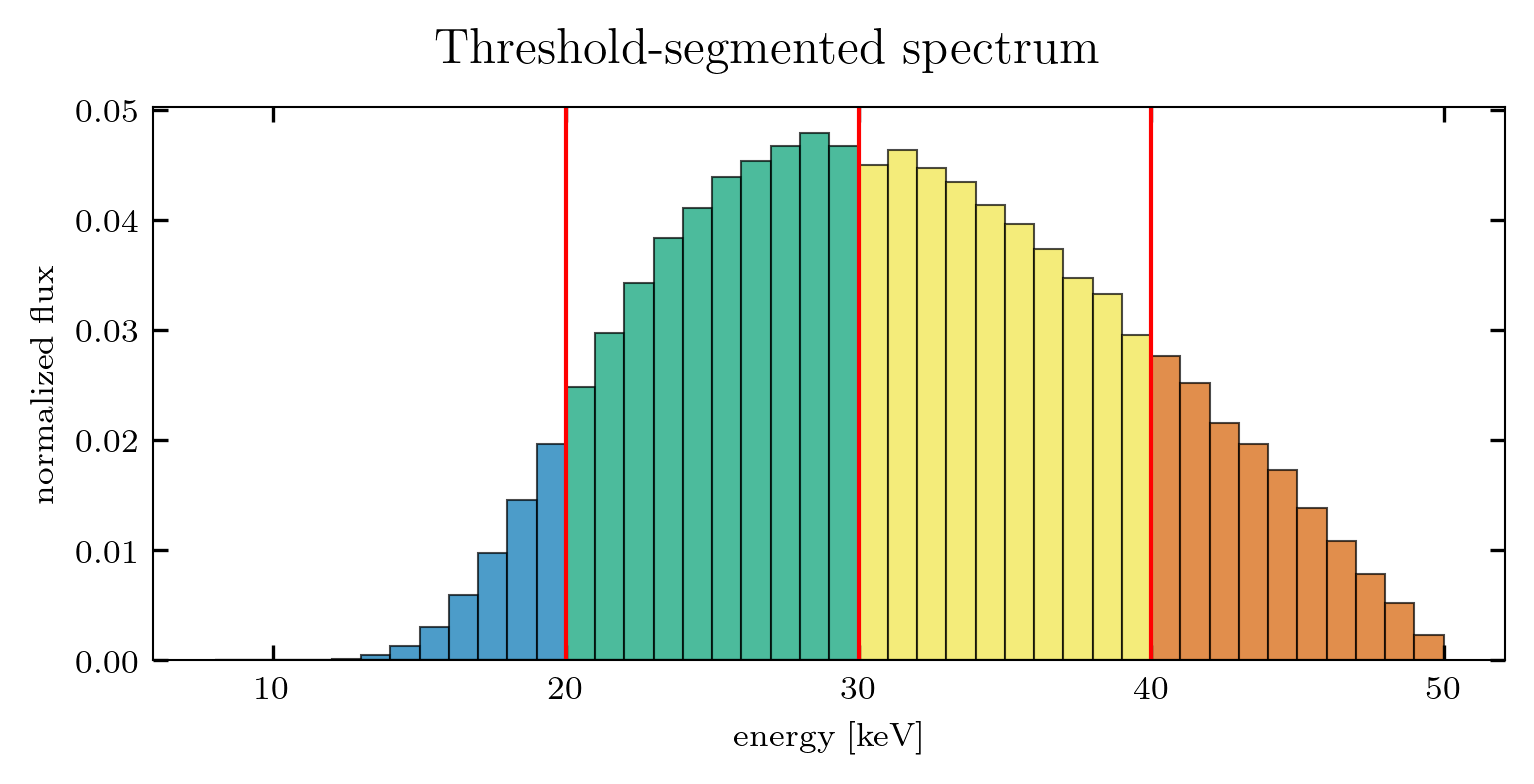

In [5]:
# Spectral imaging -- multiple detector bins

def make_binspec(energies, I0s, thresholds):
    """
    For spectral imaging, create multiple "binned" spectra, 
    i.e. the effective polychromatic spectrum detected above/below 
    an idealized energy-discriminating threshold.
    """
    E  = jnp.asarray(energies)
    I  = jnp.asarray(I0s)
    thr = jnp.sort(jnp.asarray(thresholds))
    edges = jnp.concatenate([jnp.array([-jnp.inf]), thr, jnp.array([jnp.inf])])
    lo, hi = edges[:-1][:, None], edges[1:][:, None]  # [B,1], [B,1]
    mask = (E[None, :] >= lo) & (E[None, :] < hi)     # [B,E], half-open bins
    return mask.astype(E.dtype) * I[None, :]                     


threshs = [20, 30, 40]  # example energy thresholds [keV]
specs = make_binspec(spectrum[0], spectrum[1], threshs)

fig, ax = plt.subplots(figsize=[5,2.5], dpi=300, layout='constrained')
fig.suptitle('Threshold-segmented spectrum')
ax.set_ylabel('normalized flux')
ax.set_xlabel('energy [keV]')
for i in range(len(threshs)+1):
    ax.bar(spectrum[0], specs[i], width=1, align='center', edgecolor='k', linewidth=0.5, alpha=0.7)
[ax.axvline(en, color='r') for en in threshs]
plt.show()

# Generate calcification phantom thickness maps

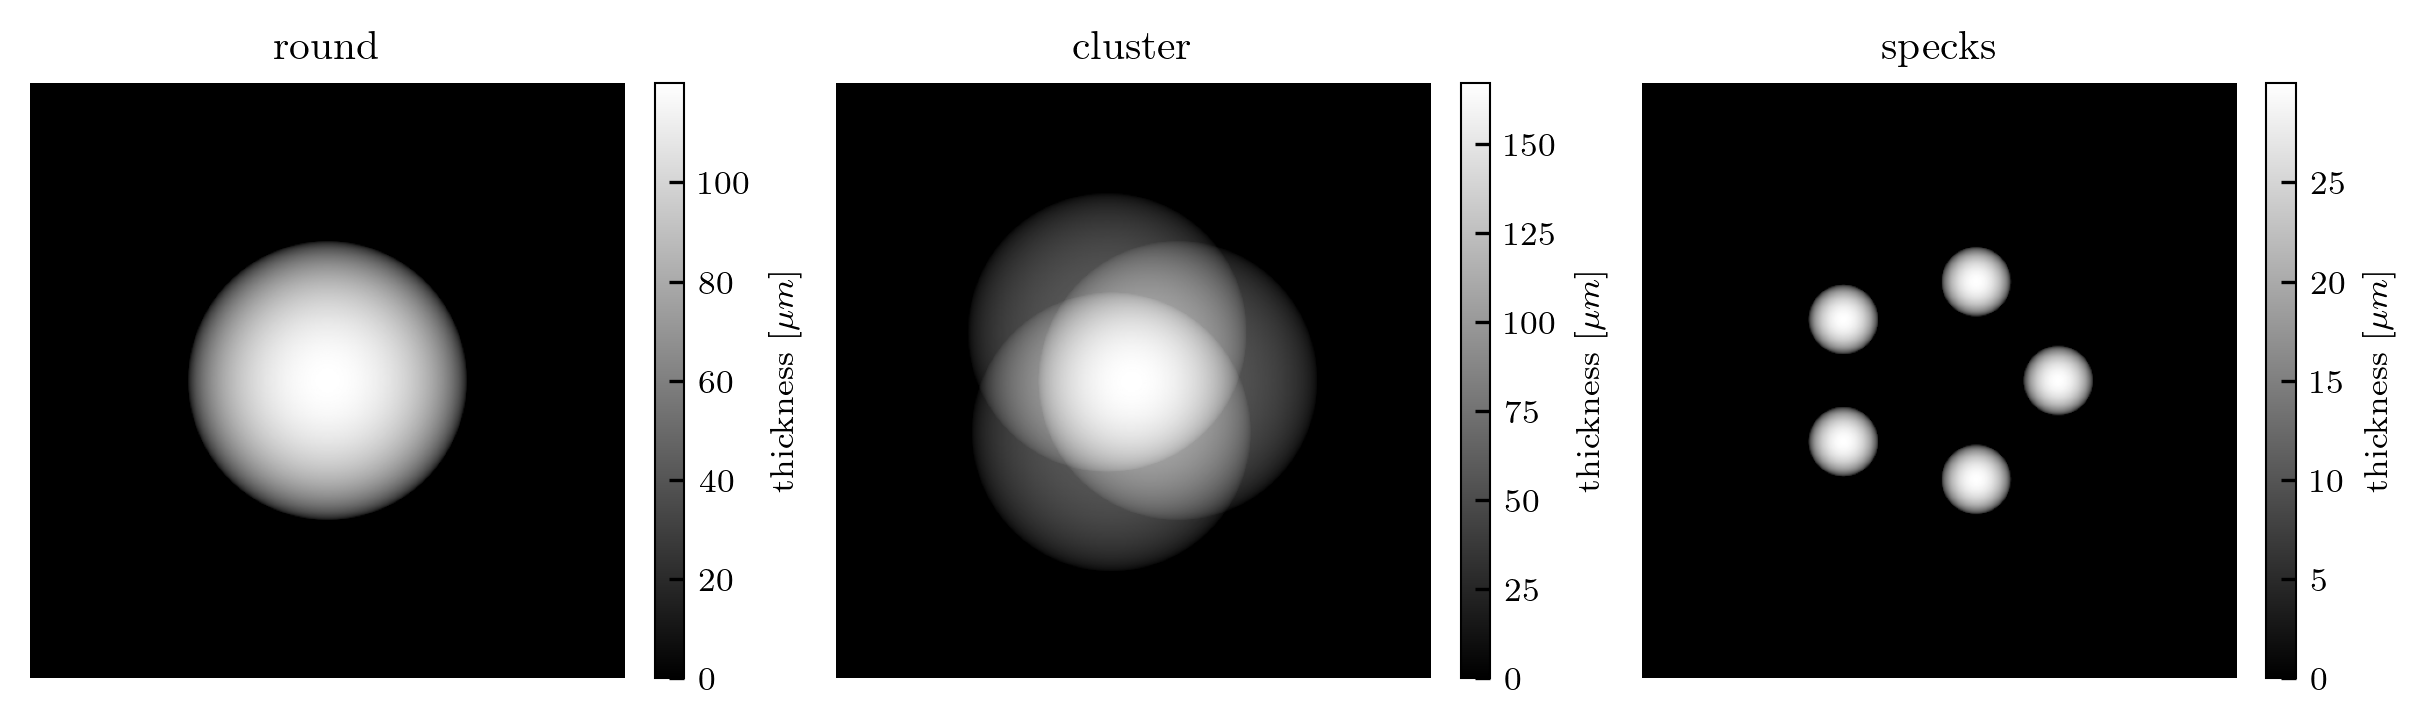

CPU times: user 478 ms, sys: 29 ms, total: 507 ms
Wall time: 486 ms


In [6]:
%%time

### Geometry for three types of calcifications
titles = ['round', 'cluster', 'specks']
T_round = 120e-6    # max thickness in [m]
T_cluster = 60e-6
T_speck = 30e-6

### Dimensions of the phantom
NX = 512     # number of pixels in x, y  
dx = 0.5e-6    # width of pixels in [m]
fov = NX*dx
yy, xx = jnp.meshgrid(jnp.arange(NX), jnp.arange(NX), indexing='ij')

### Create the thickness maps
# 1. round
x0 = y0 = (NX - 1) / 2
rr = jnp.sqrt((xx - x0)**2 + (yy - y0)**2)
r = 0.5 * (T_round / fov) * NX  
t_round   = T_round * jnp.sqrt(jnp.maximum(r**2 - rr**2, 0.0)) / r

# 2. cluster
t_cluster = jnp.zeros([NX, NX])
R0 = (NX - 1) / 2
for theta in [0, 2.1*np.pi/3, 4*np.pi/3]:
    x0 = R0 + R0*np.cos(theta)*.15
    y0 = R0 - R0*np.sin(theta)*.2
    rr = jnp.sqrt((xx - x0)**2 + (yy - y0)**2)
    t_cluster += T_cluster * jnp.sqrt(jnp.maximum(r**2 - rr**2, 0.0)) / r

# 3. specks
t_speck = jnp.zeros([NX, NX])
r = 0.5 * (T_speck / fov) * NX  
R0 = (NX - 1) / 2
for theta in np.linspace(0, 1.6*np.pi, 5):
    x0 = R0 + R0*np.cos(theta)*.4
    y0 = R0 - R0*np.sin(theta)*.35
    rr = jnp.sqrt((xx - x0)**2 + (yy - y0)**2)
    t_speck += T_speck * jnp.sqrt(jnp.maximum(r**2 - rr**2, 0.0)) / r

tmaps_bone = jnp.array([t_round, t_cluster, t_speck])

# temp - constant background thickness map, 2 cm
tmap_bg = 2e-2 * jnp.ones([NX, NX])

### Show the thickness maps
fig, ax = plt.subplots(1, 3, figsize=(8, 2.3), layout='constrained')
for i, tmap in enumerate(tmaps_bone):
    m = ax[i].imshow(tmap*1e6, vmin=0)  # scale by 1e6 so intensity is in microns
    ax[i].set_title(titles[i])
    ax[i].axis('off')
    fig.colorbar(m, ax=ax[i], label=r'thickness [$\mu m$]')
plt.show()

# Simulate an image

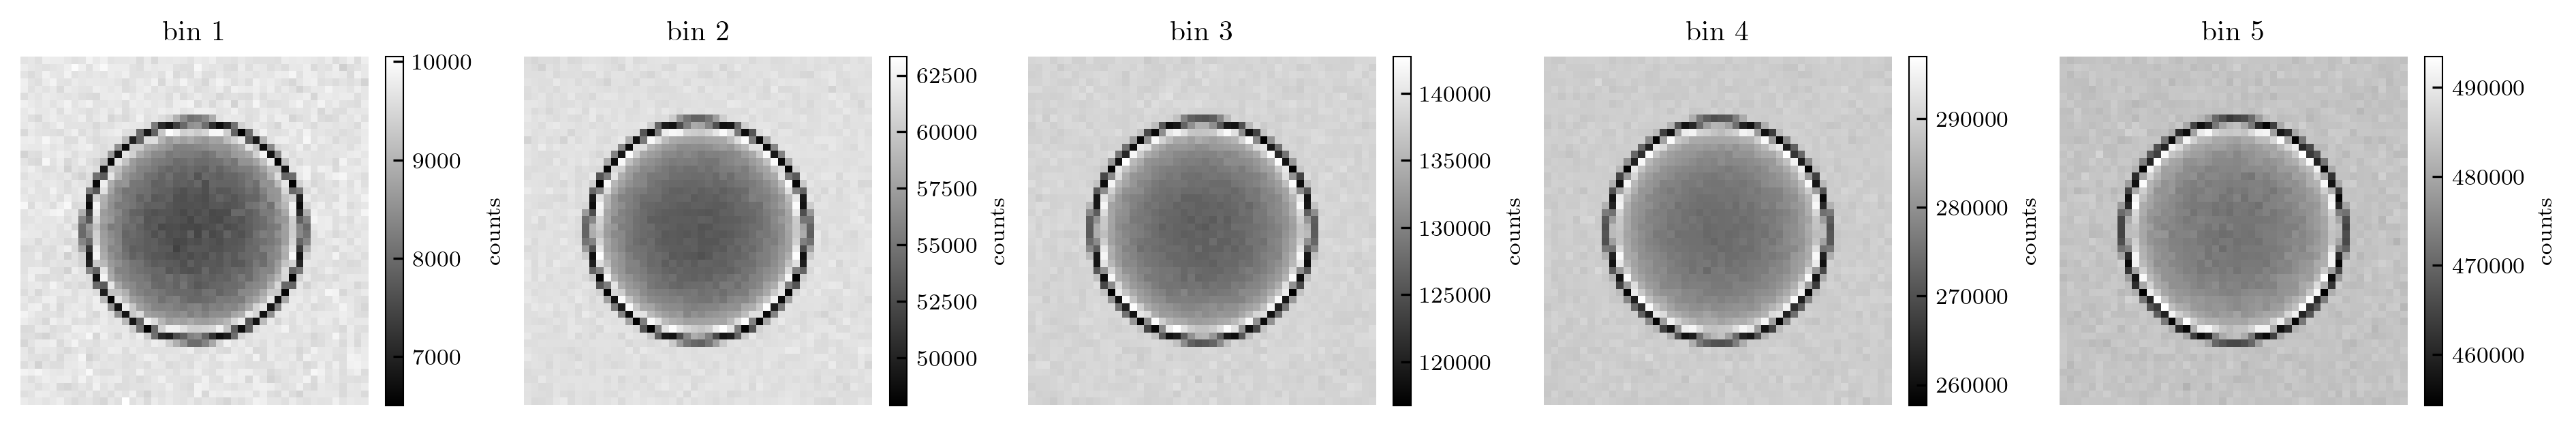

CPU times: user 5.95 s, sys: 819 ms, total: 6.77 s
Wall time: 3.15 s


In [7]:
%%time

class MultiMatProjectionSim(nn.Module):
    propdist = 50e-3
    I0_total = 1e5  # total photons per micron^2

    phantom_dx: float = 0.5e-6
    phantom_Nx: int = 512
    phantom_Ny: int = 512

    det_Nx: int = 64
    det_Ny: int = 64
    resampling_method: str = 'linear'
    det_crop: int = 8

    mats = (calc2, breast, breast)  
        
    energies = spectrum[0]                   
    wavelens = get_wavelen(energies)         

    # geometry/physics
    phantom_fov: float = phantom_Nx * phantom_dx
    det_fov: float = phantom_fov
    det_dx: float = det_fov / det_Nx
    N_pad: int = 32
    n_medium: float = 1.0

    # spectrum -- photons per energy & bin
    I0s = I0_total * spectrum[1] * (det_dx * 1e6)**2         
    thresholds = [20, 24, 28, 34]
    etas = make_binspec(energies, I0s, thresholds)               

    def setup(self):
        # parameters: thickness per material at phantom resolution
        B = len(self.mats)
        self.tmap = self.param(
            'tmap',
            lambda key, shape: jnp.full(shape, 1e-9, dtype=jnp.float32),
            (B, self.phantom_Nx, self.phantom_Ny)
        )

        # precompute delta, beta
        dbs = [m.delta_beta(self.energies) for m in self.mats]        
        self.ds = jnp.stack([d for d, _ in dbs], axis=0)      
        self.bs = jnp.stack([b for _, b in dbs], axis=0)     

        # resampler from phantom grid to detector grid
        self.det_resample_func = init_plane_resample(
            (self.det_Nx, self.det_Ny),
            (self.det_dx, self.det_dx),
            resampling_method=self.resampling_method
        )

    def __call__(self):
        # Source (multi-E)
        field = cx.plane_wave(
            shape=(self.phantom_Nx, self.phantom_Ny),
            dx=self.phantom_dx,
            spectrum=self.wavelens,
            spectral_density=jnp.ones(self.wavelens.size)
        )
        field = field / field.intensity.max()**0.5
        cval = field.intensity.max()

        # Projections (energy last: [Nx, Ny, E])
        delta_proj = jnp.einsum('bxy,be->xye', self.tmap, self.ds)
        beta_proj  = jnp.einsum('bxy,be->xye', self.tmap, self.bs)

        # Thin sample (expand to [1,Nx,Ny,E,1] for chromatix compatibility)
        exit_field = cx.thin_sample(field, beta_proj[None,..., None], delta_proj[None,..., None], 1)

        # Propagate object and vacuum with identical settings
        det_field = cx.transfer_propagate(exit_field, self.propdist, self.n_medium, self.N_pad, cval=cval, mode='same')
        ref_field = cx.transfer_propagate(field, self.propdist, self.n_medium, self.N_pad, cval=cval, mode='same')

        # Energy-resolved intensity ratio, resampled to detector grid
        A_obj = det_field.amplitude.squeeze((0, 4))
        A_ref = ref_field.amplitude.squeeze((0, 4))
        in_spacing = jnp.array([self.phantom_dx, self.phantom_dx], dtype=A_obj.dtype)
        A_obj_rs = self.det_resample_func(A_obj, in_spacing)
        A_ref_rs = self.det_resample_func(A_ref, in_spacing)
        imgs = (A_obj_rs / (A_ref_rs + 1e-12))**2   # small eps in case div by 0 error

        # Crop to get rid of edge artifacts
        dc = self.det_crop
        if dc:
            imgs = imgs[dc:self.det_Nx - dc, dc:self.det_Ny - dc, :]

        # Poisson noise per energy, then bin to polychromatic counts
        rng = self.make_rng('noise')
        imgs = jax.random.poisson(rng, imgs * self.I0s[None, None, :]).astype(imgs.dtype) \
               / (self.I0s[None, None, :] + 1e-12)
        bin_imgs = jnp.einsum('be,hwe->bhw', self.etas, imgs)  # counts per bin

        return bin_imgs.clip(0, None)

### Initialize the model
key = jax.random.PRNGKey(3)
model = MultiMatProjectionSim()
params = model.init(key)  

### Create a test phantom and insert into model
tmap_phantom = jnp.stack((t_round, tmap_bg, tmap_bg), axis=0).astype(jnp.float32)
GT = jnp.stack((t_round, tmap_bg), axis=0).astype(jnp.float32)  # for later
params = freeze({**unfreeze(params), 'params': {**unfreeze(params)['params'], 'tmap': tmap_phantom}})

### Simulate data
data = model.apply(params, rngs={'noise': key})

### Show bin images
Nt = data.shape[0]
fig, ax = plt.subplots(1, Nt, figsize=[2.5*Nt, 2], layout='constrained')
for i in range(Nt):
    ax[i].set_title(f'bin {i+1}')
    m = ax[i].imshow(data[i])
    fig.colorbar(m, ax=ax[i], label='counts')
    ax[i].axis('off')
plt.show()

# Reconstruct

Note the class above was called `MultiMatProjectionSim`. Here we use a nearly identical class, `MultiMatProjectionOpt`, which is a slightly simplified forward model. The reason is, for the simulation, we only call the class once and want the outputs to be as faithful to reality as possible. But for the optimizer, we are calling the class many times as we minimize the loss function and calculate gradients over several iterations, so we might relax the forward model a bit to improve performance while still being pretty realistic. There are also a few other things:

- The input materials are different; for the optimizer, we assume a set of just two "basis materials" regardless of how many are truly used in the simulation.
- The phantom resolution can be lower, closer to the detector resolution, since we reconstruct at a lower resolution than the ground truth. This also means we need extra up-sampling functions in the optimizer class.
- There is no Poisson noise added.

Right now all the inputs are hard-coded to match between the two classes, but there is probably a less error-prone way to do this.

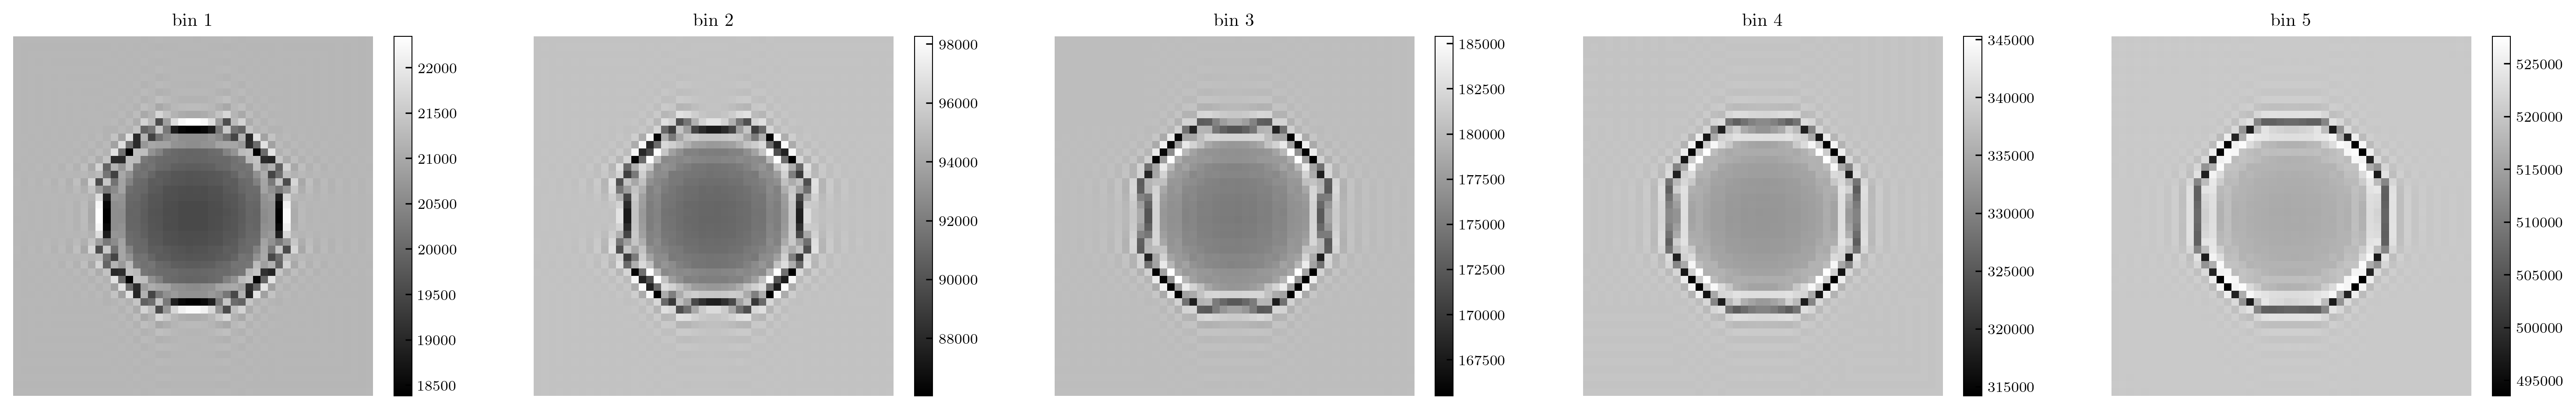

In [8]:
class MultiMatProjectionOpt(nn.Module):
    propdist = 50e-3
    I0_total = 1e5  # total photons per micron^2

    phantom_dx: float = 4e-6 #1e-6
    phantom_Nx: int = 64 #256     # opt vs sim --- lower res, no phantom-detector upsampling
    phantom_Ny: int = 64 #256

    det_Nx: int = 64
    det_Ny: int = 64
    resampling_method: str = 'linear'
    det_crop: int = 8

    mat1 = bone
    mat2 = water 
    energies = spectrum[0]
    ds1, bs1 = mat1.delta_beta(energies)
    ds2, bs2 = mat2.delta_beta(energies)
    n1 = (ds1 + 1j*bs1) / mat1.density
    n2 = (ds2 + 1j*bs2) / mat2.density

    ds = jnp.stack((ds1, ds2), axis=0)  
    bs = jnp.stack((bs1, bs2), axis=0)  

    phantom_fov: float = phantom_Nx * phantom_dx
    det_fov: float = phantom_fov
    det_dx: float = det_fov / det_Nx
    wavelens = get_wavelen(energies)
    N_pad: int = 32
    n_medium: float = 1.0

    I0s = I0_total * spectrum[1] * (det_dx * 1e6)**2
    thresholds = [20, 24, 28, 34]
    etas = make_binspec(energies, I0s, thresholds)               

    # optimization set-up
    t_guess_bone_m: float = det_dx     # ~1 um     
    t_guess_tissue_m: float = 1e-2     # 1 cm
    init_jitter_frac: float = 0.001     # 1% jitter to break symmetry; set 0 to disable
    init_scale: float = 1

    t_guess_bone_m *= init_scale
    t_guess_tissue_m *= init_scale
    
    def setup(self):
        
        H = self.det_Nx - 2*self.det_crop
        W = self.det_Ny - 2*self.det_crop

        def init_tmap(key, shape):
            # per-material guesses with light jitter
            k1, k2 = jax.random.split(key)
            bone_guess   = jnp.full((H, W), self.t_guess_bone_m,   dtype=jnp.float32)
            tissue_guess = jnp.full((H, W), self.t_guess_tissue_m, dtype=jnp.float32)
    
            if self.init_jitter_frac > 0:
                bone_guess   = bone_guess + (1e-7)   * jax.random.normal(k1, (H, W)).astype(jnp.float32)
                tissue_guess = tissue_guess + (1e-7) * jax.random.normal(k2, (H, W)).astype(jnp.float32)
    
            t0 = jnp.clip(bone_guess,   1e-8)  # enforce non-negativity at init
            t1 = jnp.clip(tissue_guess, 1e-8)
            return jnp.stack((t0, t1), axis=0)
    
        self.tmap = self.param('tmap', init_tmap, (2, H, W))
        
        self.det_resample_func = init_plane_resample(
            (self.det_Nx, self.det_Ny),
            (self.det_dx, self.det_dx),
            resampling_method=self.resampling_method
        )
        self.upsample_to_phantom = init_plane_resample(
            (self.phantom_Nx, self.phantom_Ny),
            (self.phantom_dx, self.phantom_dx),
            resampling_method='cubic'
        )

    def __call__(self):
        # Upsample tmap (length units only; no area scaling)
        dc = self.det_crop
        in_spacing = jnp.array([self.det_dx, self.det_dx])
        tmap_padded = jnp.pad(self.tmap, ((0, 0), (dc, dc), (dc, dc)), mode='edge')
        tmp = self.upsample_to_phantom(jnp.moveaxis(tmap_padded, 0, -1), in_spacing)
        tmap_upx = jnp.moveaxis(tmp, -1, 0) * (self.det_dx / self.phantom_dx)**2

        # Source (multi-E)
        field = cx.plane_wave(
            shape=(self.phantom_Nx, self.phantom_Ny),
            dx=self.phantom_dx,
            spectrum=self.wavelens,
            spectral_density=jnp.ones(self.wavelens.size)
        )
        field = field / field.intensity.max()**0.5
        cval = field.intensity.max()

        # Projections (energy last: [Nx, Ny, E])
        delta_proj = jnp.einsum('bxy,be->xye', tmap_upx, self.ds)
        beta_proj  = jnp.einsum('bxy,be->xye', tmap_upx, self.bs)

        # Thin sample
        exit_field = cx.thin_sample(field, beta_proj[None, ..., None],
                                    delta_proj[None, ..., None], 1)

        # Propagate object and vacuum
        det_field = cx.transfer_propagate(exit_field, self.propdist, self.n_medium,
                                          self.N_pad, cval=cval, mode='same')
        ref_field = cx.transfer_propagate(field,      self.propdist, self.n_medium,
                                          self.N_pad, cval=cval, mode='same')

        # ENERGY-RESOLVED intensity ratio at detector grid
        A_obj = det_field.amplitude.squeeze((0, 4))
        A_ref = ref_field.amplitude.squeeze((0, 4))
        in_spacing = jnp.array([self.phantom_dx, self.phantom_dx], dtype=A_obj.dtype)
        A_obj_rs = self.det_resample_func(A_obj, in_spacing)
        A_ref_rs = self.det_resample_func(A_ref, in_spacing)
        imgs = (A_obj_rs / (A_ref_rs + 1e-12))**2  # [det_Nx, det_Ny, E]

        # Optional crop, then polychromatic binning to counts
        if dc:
            imgs = imgs[dc:self.det_Nx - dc, dc:self.det_Ny - dc, :]

        bin_imgs = jnp.einsum('be,hwe->bhw', self.etas, imgs)  # counts per bin

        return bin_imgs.clip(0, None)


# ---- build params & phantom ----
model = MultiMatProjectionOpt()
params = model.init(key)  

Nx = model.det_Nx - 2*model.det_crop
fov = Nx * model.det_dx 
yy, xx = jnp.meshgrid(jnp.arange(Nx), jnp.arange(Nx), indexing='ij')
x0 = y0 = (Nx - 1) / 2
rr = jnp.sqrt((xx - x0)**2 + (yy - y0)**2)
T_bone_center = 100e-6
r =  0.5 * (T_bone_center / fov) * Nx  #0.2 * fov / model.det_dx
t_tissue1 = jnp.full((Nx, Nx), 2e-2, dtype=jnp.float32)
t_bone1   = T_bone_center * jnp.sqrt(jnp.maximum(r**2 - rr**2, 0.0)) / r
tmap_phantom = jnp.stack((t_bone1, t_tissue1), axis=0).astype(jnp.float32)
params = freeze({**unfreeze(params), 'params': {**unfreeze(params)['params'], 'tmap': tmap_phantom}})

# # GT for later plotting. This is an approximation, non-uniform BG.
# GT = jnp.stack((t_bone1, t_tissue1), axis=0).astype(jnp.float32)

# ---- simulate ----
forward = jax.jit(model.apply)
test = forward(params) 

fig, ax = plt.subplots(1, len(test), dpi=300, figsize=[4*len(test),3], layout='constrained')
for i in range(len(test)):
    ax[i].set_title(f'bin {i+1}')
    m = ax[i].imshow(test[i,:,:], cmap='gray')
    fig.colorbar(m, ax=ax[i])
    ax[i].axis('off')
plt.show()

## Optimizer

In [9]:
def poisson_nll(yhat, y, eps=1e-12):
    return jnp.mean(yhat - y * jnp.log(yhat + eps))

def TV(x, eps=1e-8):
    dx = jnp.diff(x, axis=0, append=x[-1:, :])   
    dy = jnp.diff(x, axis=1, append=x[:, -1:])   
    eps = jnp.asarray(eps, dtype=x.dtype)
    return jnp.sum(jnp.sqrt(dx*dx + dy*dy + eps*eps))
    
def L1(x):
    return jnp.sum(jnp.abs(x))

In [10]:
def plot_md_results(params, gt, cmap='viridis', show=True, match_kw=True, C=1e3):
    """
    Helper function to show ground truth (gt) vs estimated thickness maps.
    """
    tmap_est = params.get('tmap', params['params']['tmap'])  # supports both flat/nested params

    if match_kw:
        cmap = 'bwr'
        kw1 = {'cmap':'bwr', 'vmin':0, 'vmax':C * 2 * gt[0].max()}
        kw2 = {'cmap':'bwr', 'vmin':0, 'vmax':C * 2 * gt[1].max()}
    else:
        kw1 = {'cmap':cmap}
        kw2 = {'cmap':cmap}
        
    fig, axs = plt.subplots(1, 4, figsize=(12, 3), constrained_layout=True)
    ims = [
        axs[0].imshow(C * gt[0], **kw1),
        axs[1].imshow(C * tmap_est[0], **kw1),
        axs[2].imshow(C * gt[1], **kw2),
        axs[3].imshow(C * tmap_est[1], **kw2)
    ]
    titles = ['Mat1 GT', 'Mat1 est', 'Mat2 GT', 'Mat2 est']
    for ax, im, title in zip(axs, ims, titles):
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if show:
        plt.show()
    else:
        return fig, axs

loss @ iter 100: -2.235006e+06 (t = 1.7 s)
Fidelity ~ -2.24e+06  / TV1 ~ 3.43e-07  / TV2 ~ 3.03e-07


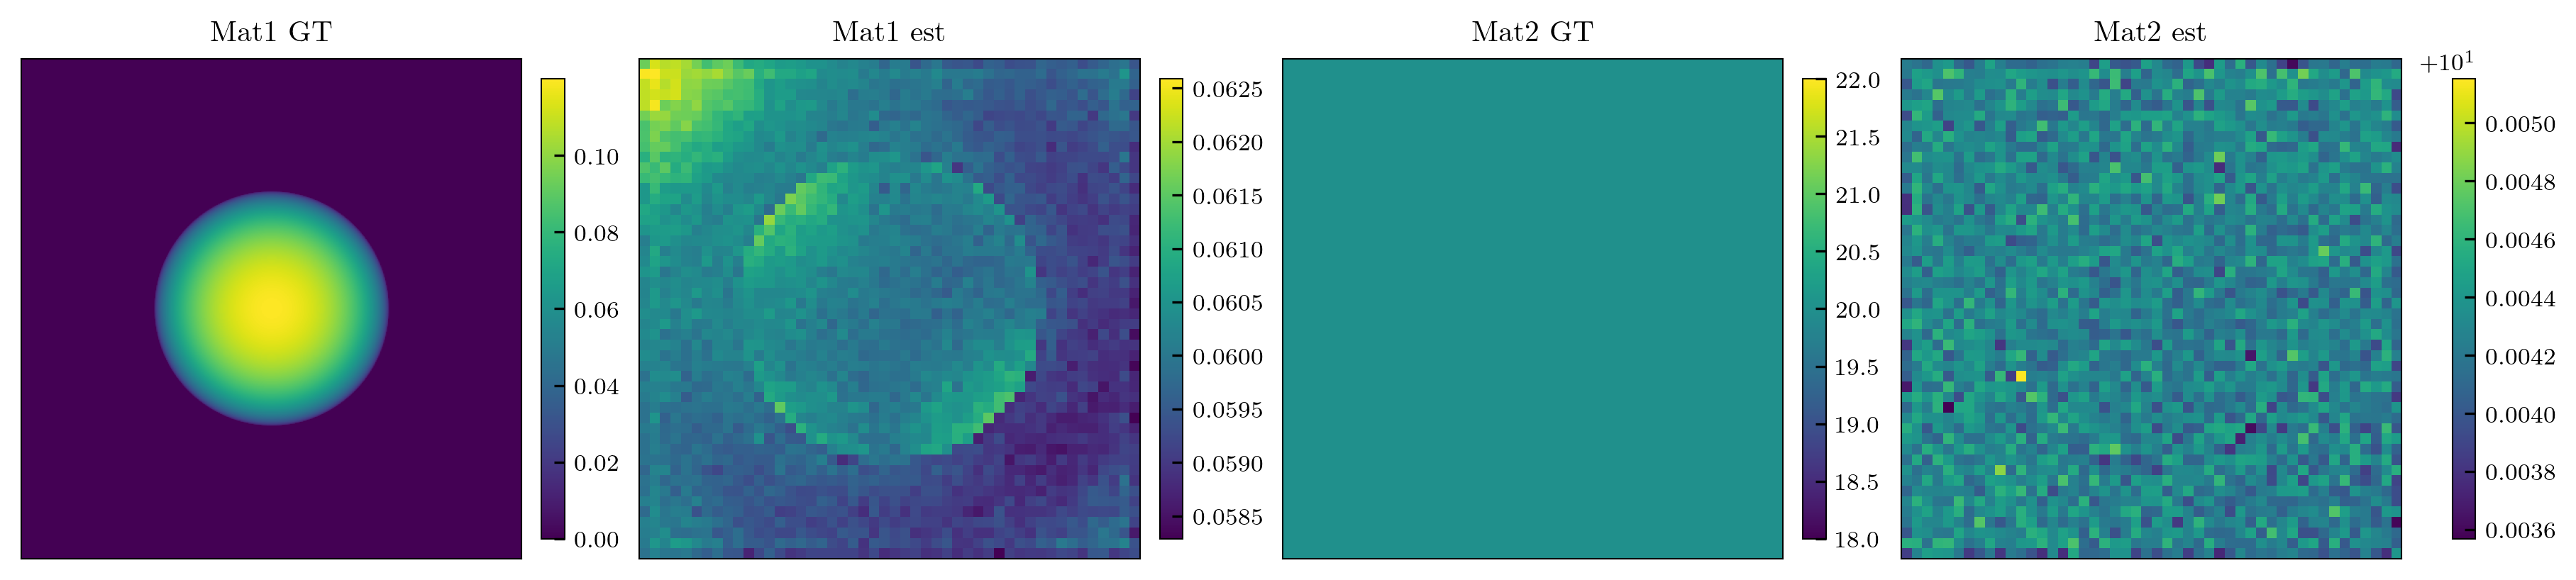

loss @ iter 200: -2.236289e+06 (t = 3.1 s)
Fidelity ~ -2.24e+06  / TV1 ~ 3.62e-07  / TV2 ~ 3.02e-07


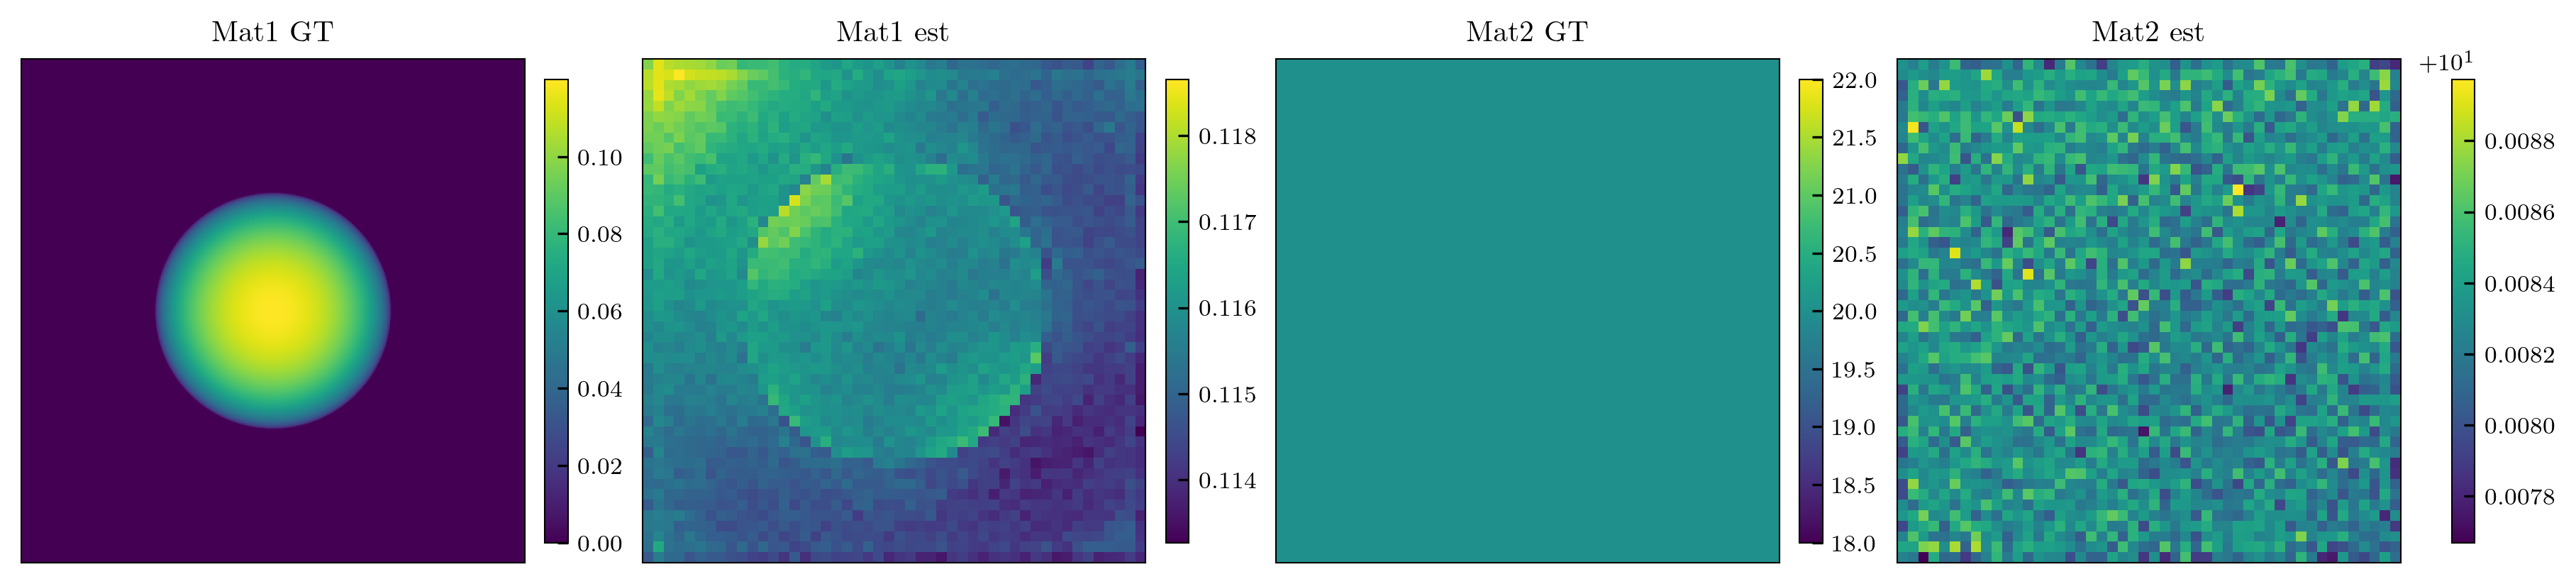

loss @ iter 300: -2.237452e+06 (t = 4.3 s)
Fidelity ~ -2.24e+06  / TV1 ~ 3.61e-07  / TV2 ~ 2.98e-07


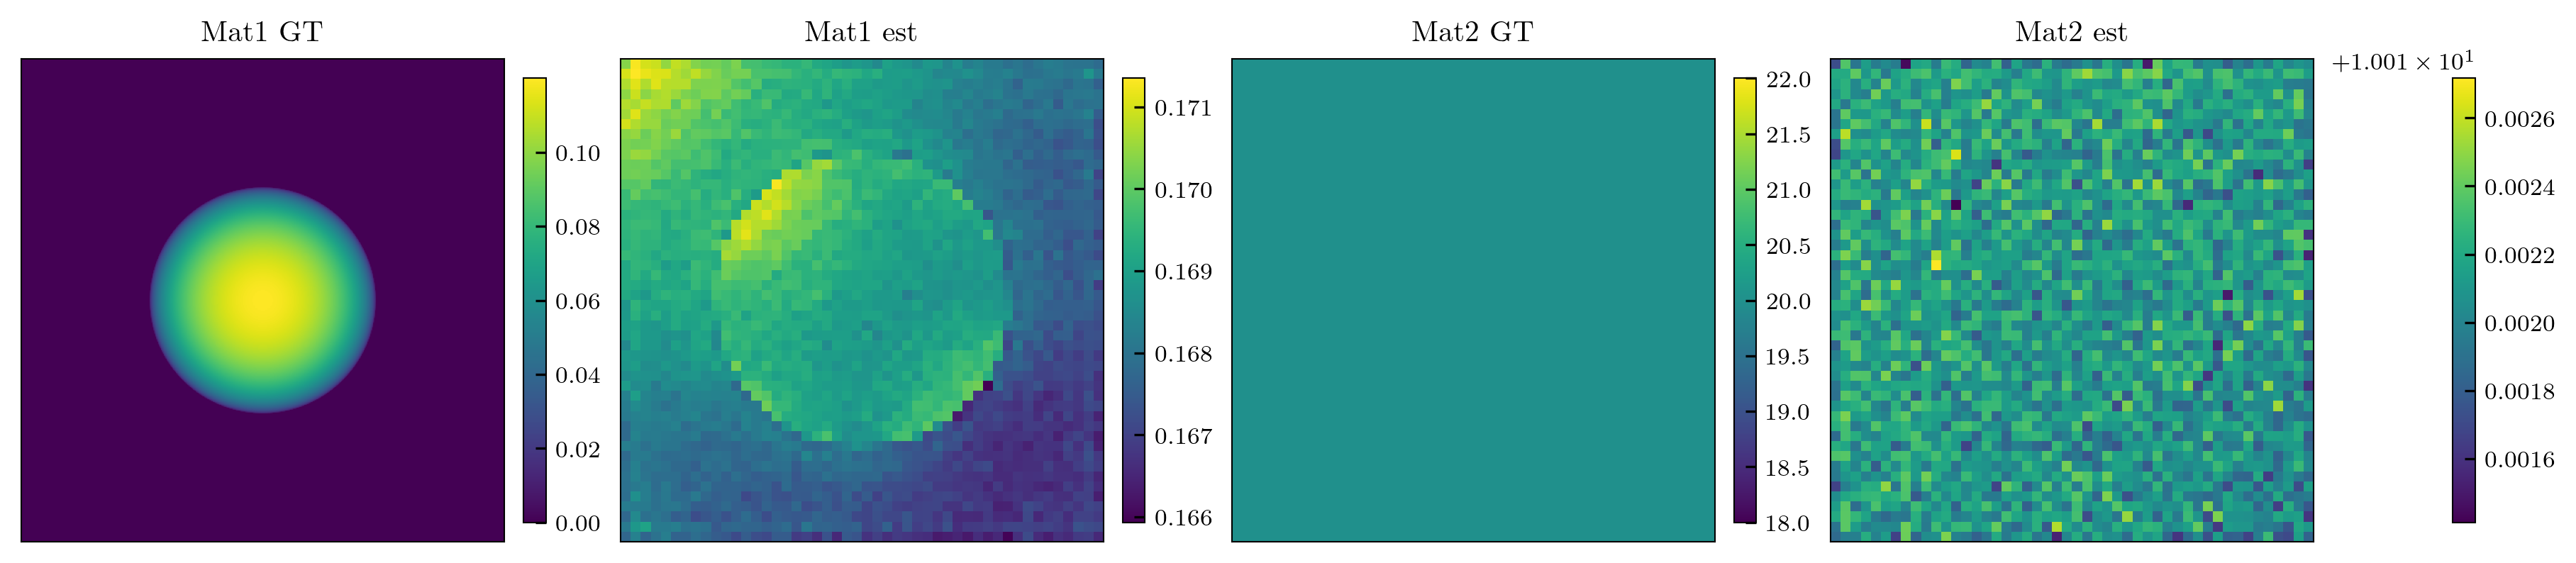

loss @ iter 400: -2.238502e+06 (t = 5.6 s)
Fidelity ~ -2.24e+06  / TV1 ~ 3.58e-07  / TV2 ~ 2.97e-07


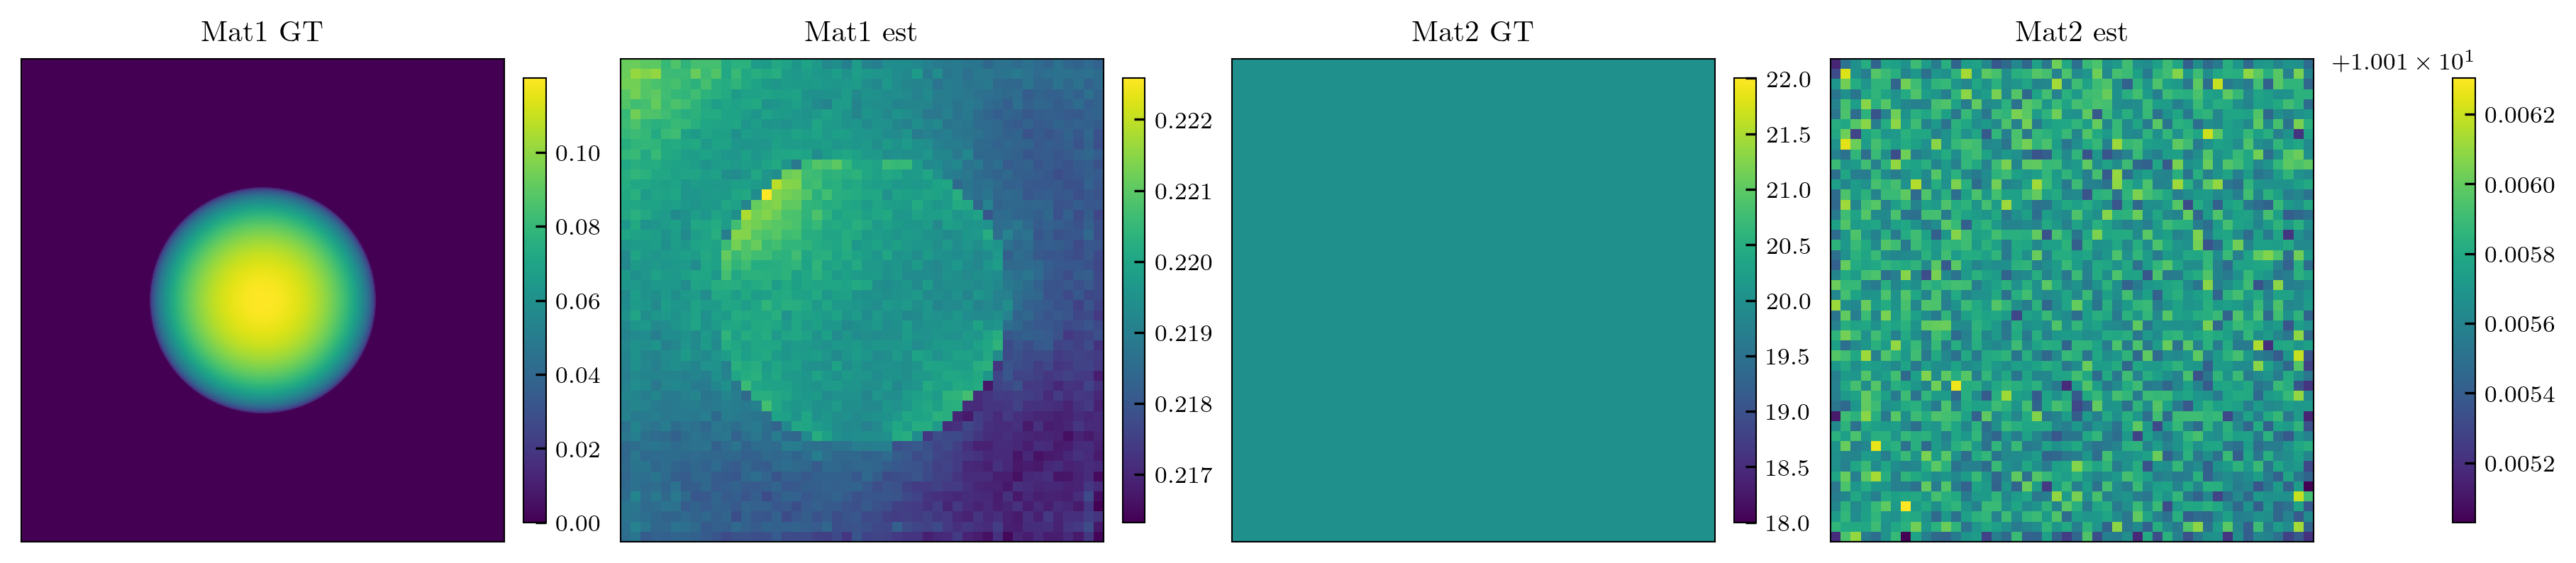

loss @ iter 500: -2.239453e+06 (t = 6.9 s)
Fidelity ~ -2.24e+06  / TV1 ~ 3.53e-07  / TV2 ~ 3.05e-07


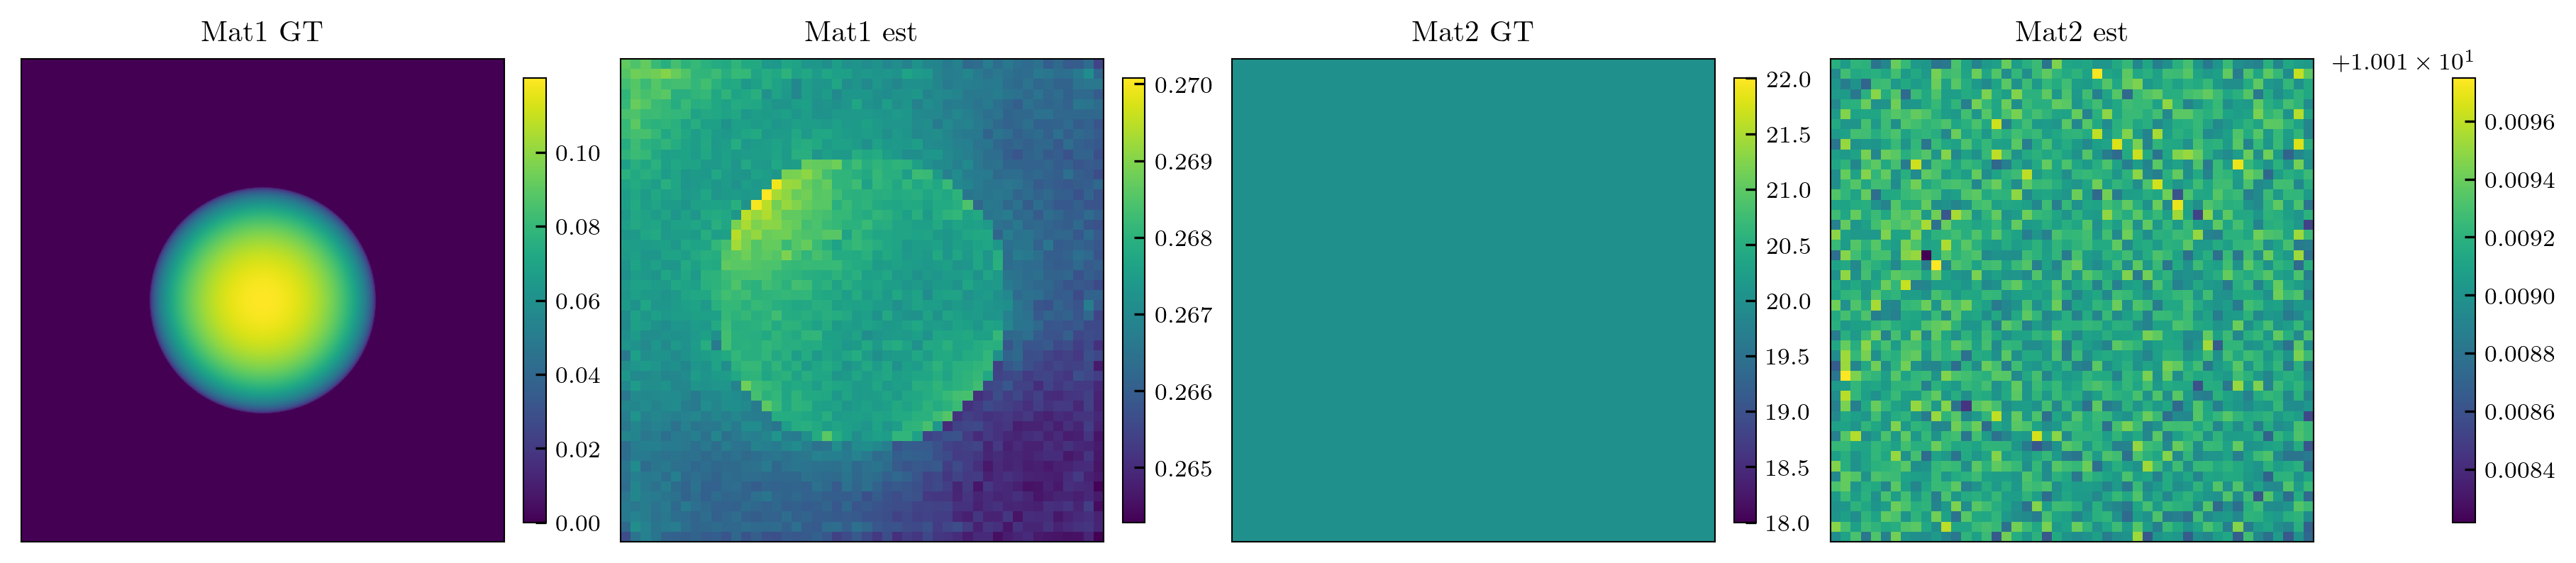

loss @ iter 600: -2.240310e+06 (t = 8.2 s)
Fidelity ~ -2.24e+06  / TV1 ~ 3.63e-07  / TV2 ~ 2.99e-07


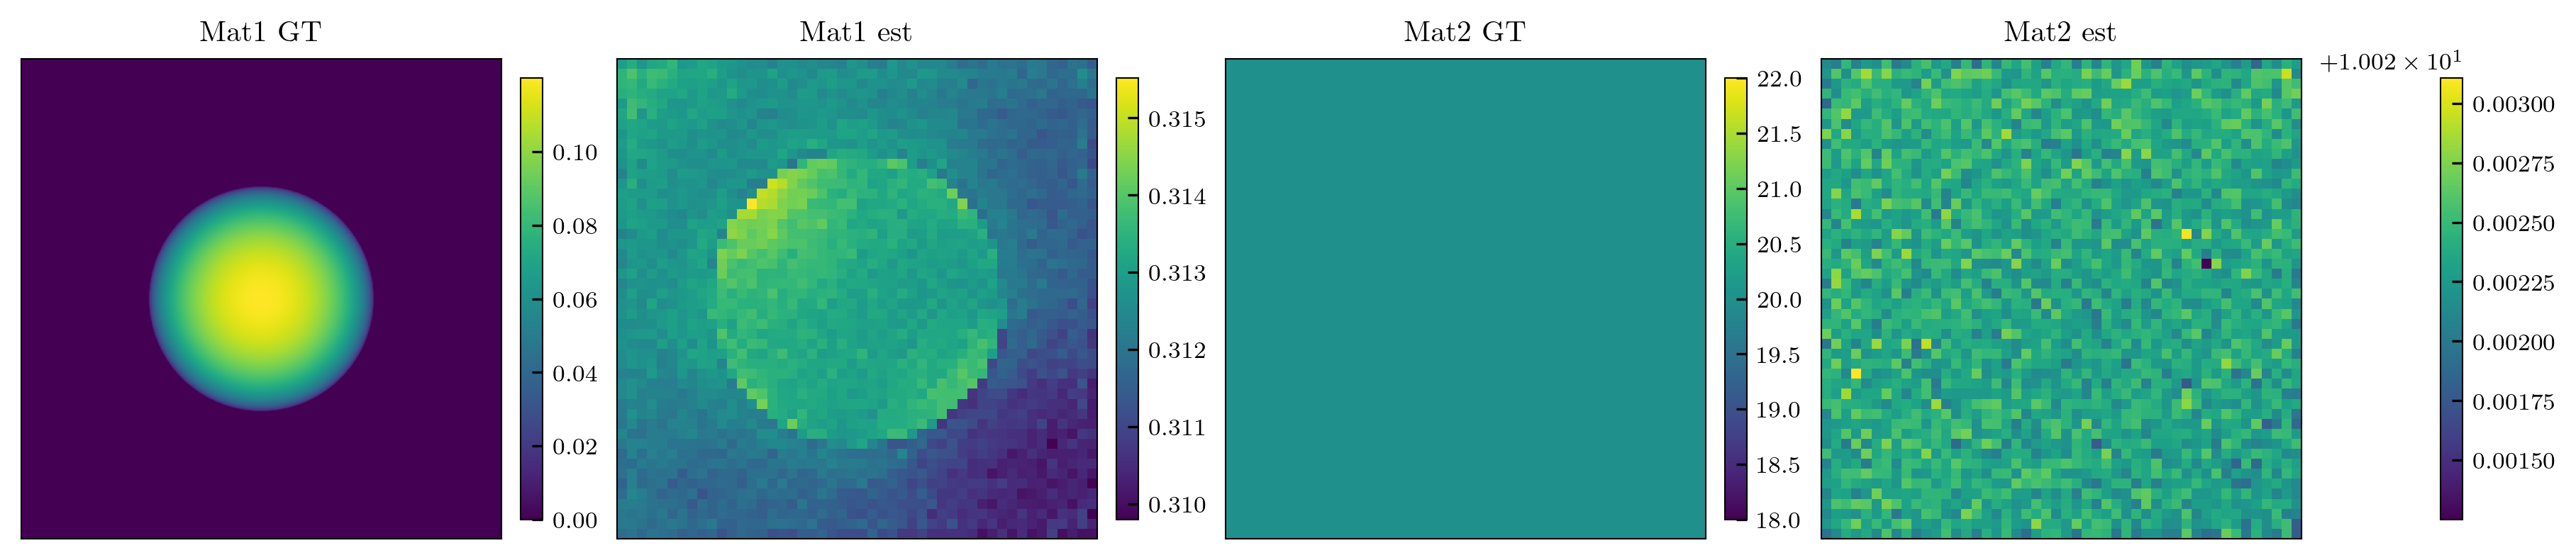

loss @ iter 700: -2.241094e+06 (t = 9.5 s)
Fidelity ~ -2.24e+06  / TV1 ~ 3.63e-07  / TV2 ~ 3.02e-07


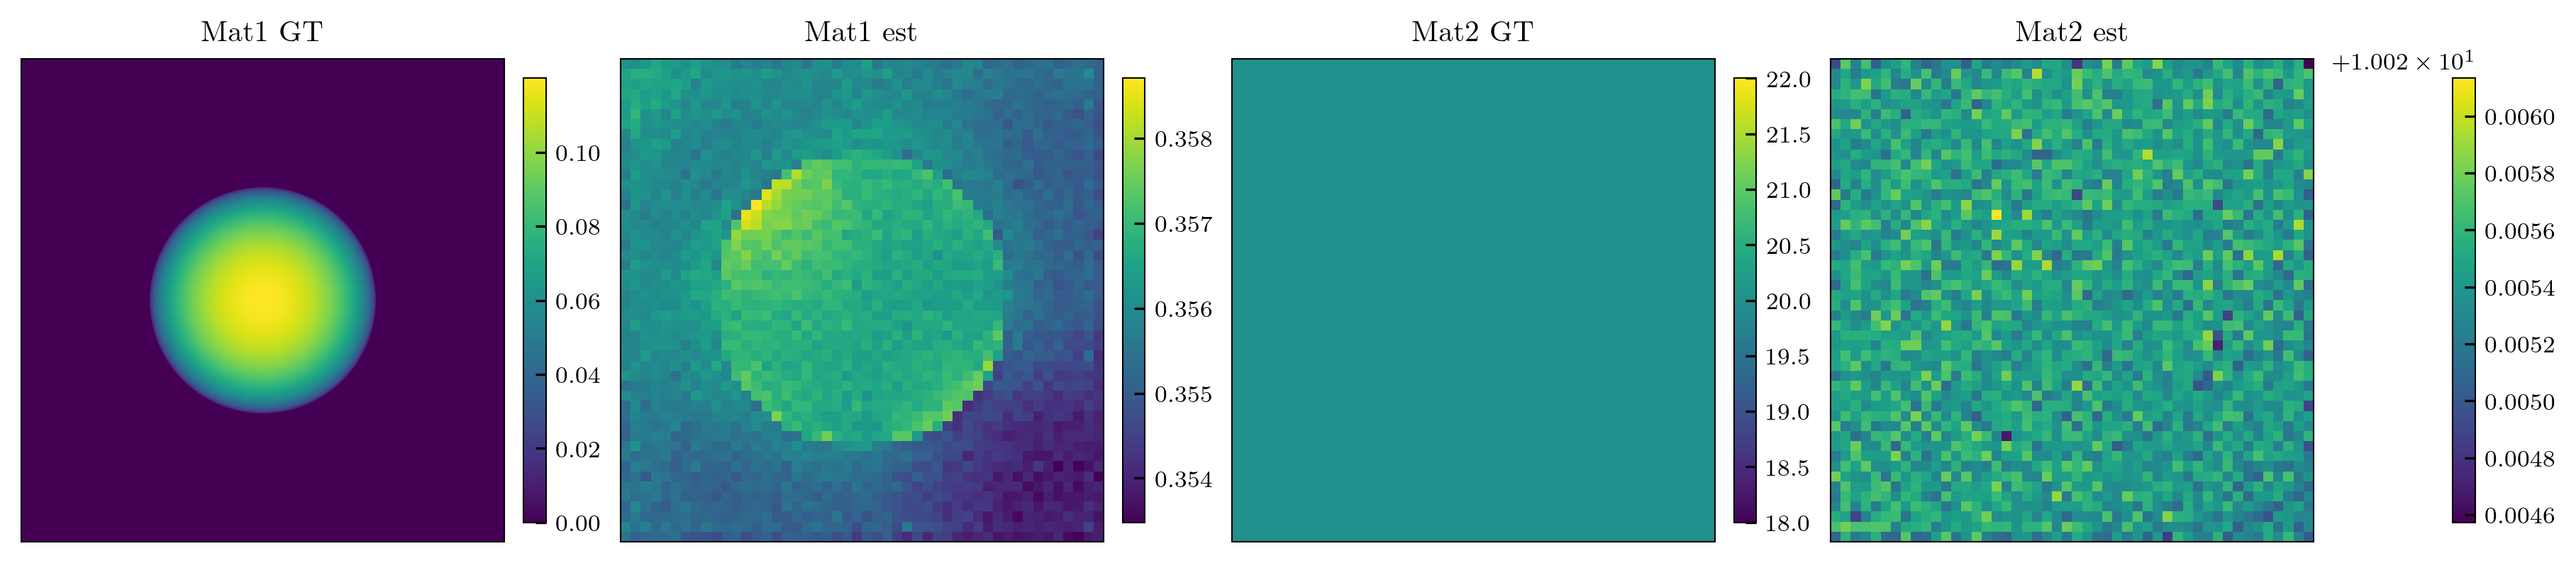

loss @ iter 800: -2.241806e+06 (t = 10.8 s)
Fidelity ~ -2.24e+06  / TV1 ~ 3.48e-07  / TV2 ~ 2.98e-07


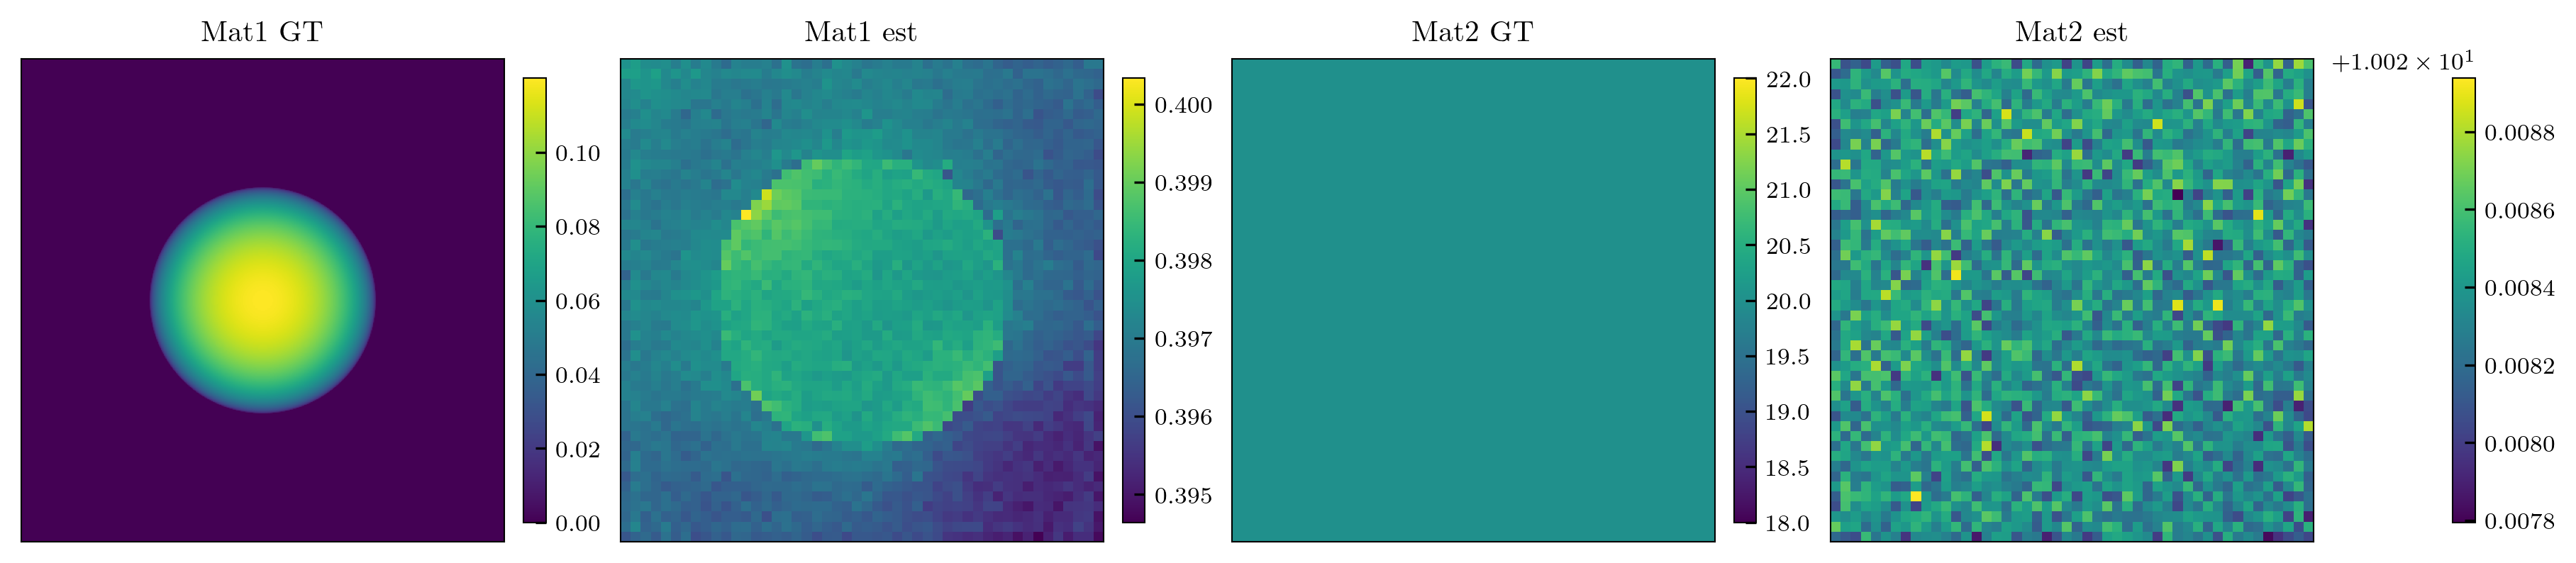

loss @ iter 900: -2.242456e+06 (t = 12.0 s)
Fidelity ~ -2.24e+06  / TV1 ~ 3.57e-07  / TV2 ~ 2.99e-07


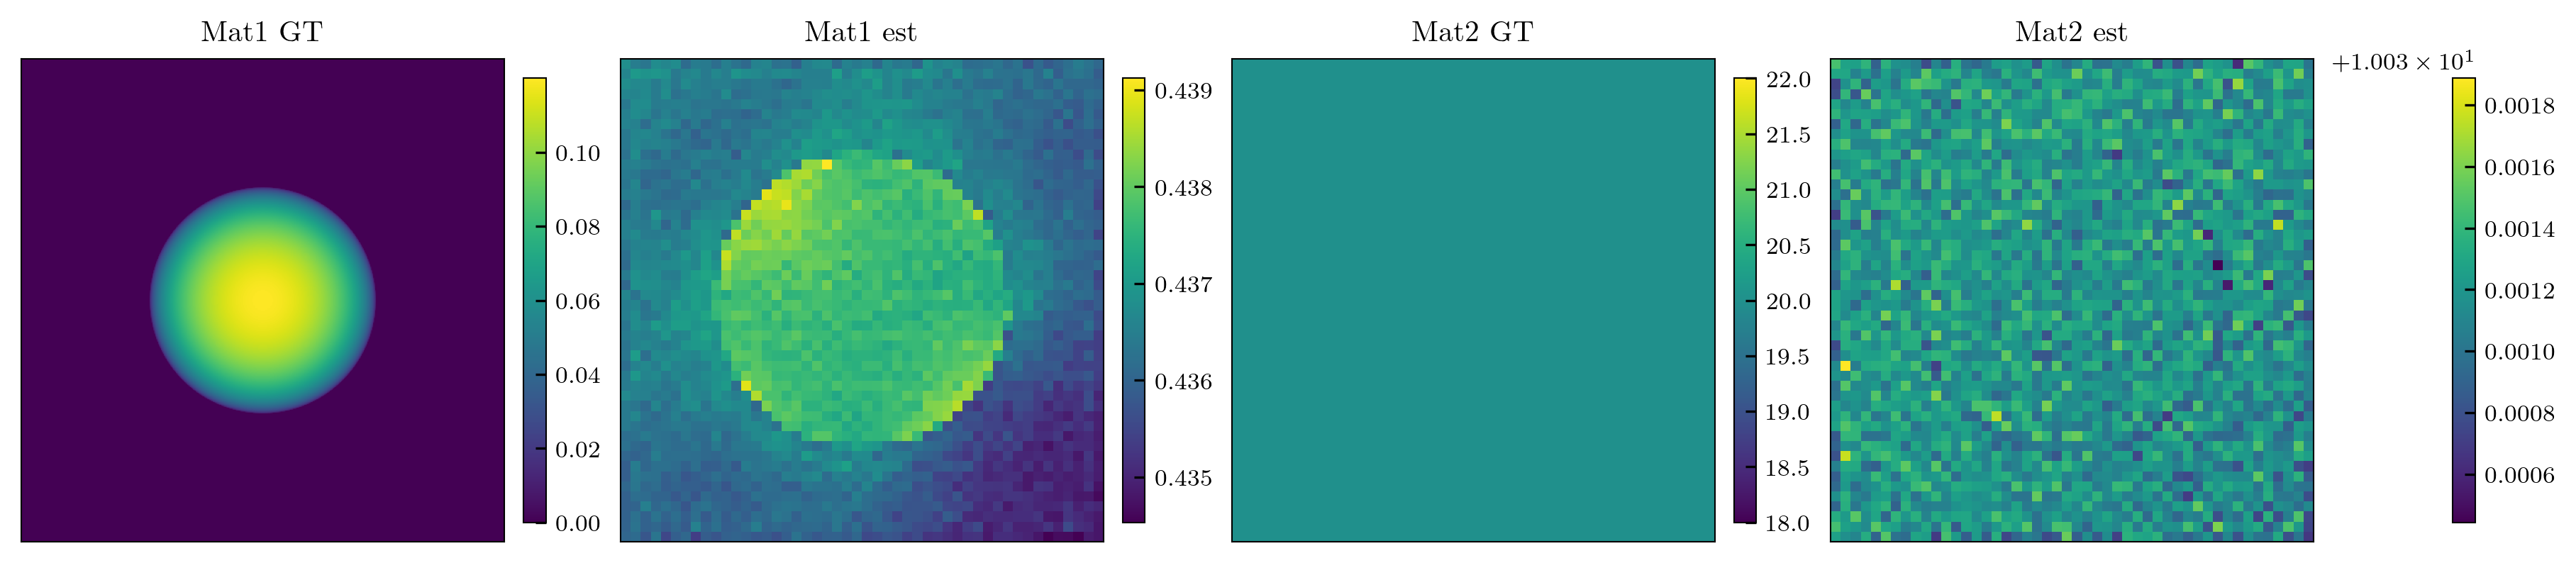

loss @ iter 1000: -2.243054e+06 (t = 13.3 s)
Fidelity ~ -2.24e+06  / TV1 ~ 3.57e-07  / TV2 ~ 2.92e-07


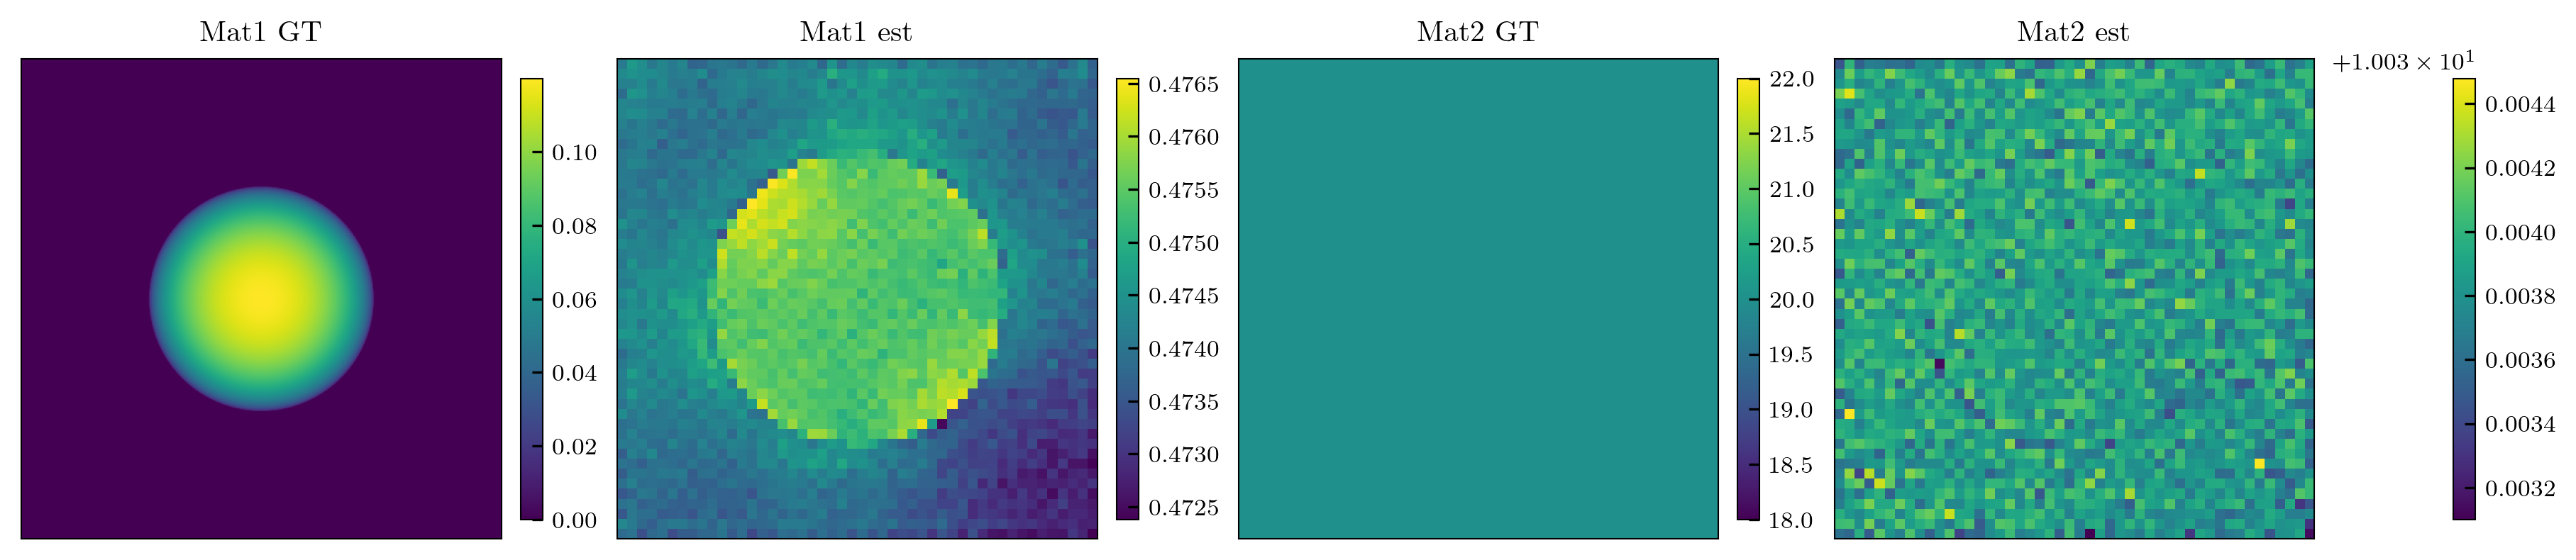

CPU times: user 25.3 s, sys: 3.12 s, total: 28.4 s
Wall time: 13.6 s


In [11]:
%%time

# ---------- Hyperparams ----------
LRATE = 2e-6
max_iter = 1000
show_iter = 100

w_tv1 = 4e7
w_tv2 = w_tv1

# ---------- Model / params / optimizer ----------

def loss_fn(params, data):
    # tmap = _tmaps_from_params(params)
    tmap = params.get('tmap', params['params']['tmap'])  # supports both flat/nested params
    t1, t2 = tmap[0], tmap[1]

    y_k = forward(params)
    fidelity = poisson_nll(y_k, data)

    tv1 = w_tv1 * TV(t1) / t1.size 
    tv2 = w_tv2 * TV(t2) / t2.size
    
    return fidelity + tv1 + tv2 


##
key = jax.random.PRNGKey(3)
model = MultiMatProjectionOpt()
forward = jax.jit(model.apply)

##
params = model.init(key)
##

optimizer = optax.chain(
    optax.clip_by_global_norm(5.0),
    optax.adam(learning_rate=LRATE, eps=1e-8),
)
opt_state = optimizer.init(params)


@jax.jit
def update(params, opt_state, *args):
    loss, grads = jax.value_and_grad(loss_fn)(params, *args)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = projection_non_negative(optax.apply_updates(params, updates))
    return params, opt_state, loss


# ---------- Train ----------
loss = []
t0 = time()
for k in range(max_iter + 1):

    params, opt_state, loss_k = update(params, opt_state, data)
    loss.append(loss_k)

    if k % show_iter == 0 and k > 0:
        t1, t2 = params['params']['tmap']
        y0 = forward(params); tv1 = TV(t1)/t1.size; tv2 = TV(t2)/t2.size
        fidel = jnp.mean(y0 - data * jnp.log(y0 + 1e-12))
        print(f'loss @ iter {k}: {loss_k:.6e} (t = {time()-t0:.1f} s)')
        print(f'Fidelity ~ {fidel:8.2e}  / TV1 ~ {tv1:6.2e}  / TV2 ~ {tv2:6.2e}')
        plot_md_results(params, GT, match_kw=False)
